In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Interpolation with Gaussian Processes

We are solving the following problem. Given the values of a function $f : [0, 1] \rightarrow \R$ at fixed points $0 \leq x_1 < \dots < x_n \leq 1$, what can we say about $f(x)$ for some $x$ that is distinct from $x_1, \dots, x_n$?

In [36]:
#Consider the following smooth function: 
def smoothfun(x):
    ans = np.sin(15*x) + 15*np.exp(-(x ** 3)/2) + 0.5*((x - 0.5) ** 2) + 5 * np.log(x + 0.1) + 7
    return ans

#Here is another example of a function: 
#def smoothfun(x):
#    ans = (np.sin(15*x) + 0.6*np.sin(60*x) + 0.4*np.sin(120*x) + 15*np.exp(-(x**3)/2) + 0.5*((x-0.5)**2) + 5*np.log(x+0.1) + 7)
#    return ans

#We observe this function at the following points: 
n = 5
xx = np.linspace(0, 1, n) #these are equally spaced points
xx = np.linspace(0.2, 0.8, n)
#xx = np.sort(np.random.rand(n)) #these are unequally spaced points

#these are the values of the function at the observed points, which we will treat as our data
truth = np.array([smoothfun(x) for x in xx])
y = truth

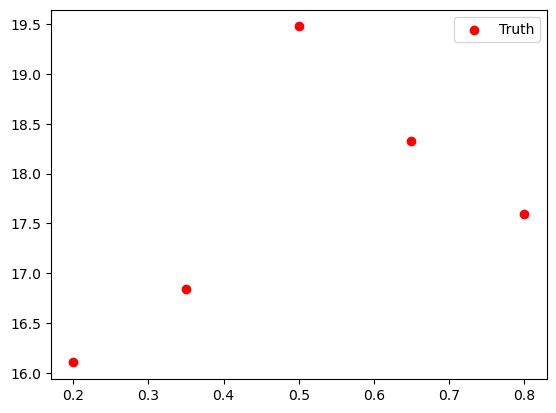

In [37]:
#Below we plot the scatter plot of the observed data
plt.scatter(xx, truth, label = 'Truth', color = 'red')
plt.legend()
plt.show()

## Interpolation using Brownian Motion

We will use the Brownian motion prior: $f(x) = \beta_0 + \tau B(x)$ with $\beta_0 \sim N(0, C)$ and $B(x)$ is Brownian motion. We will compute the posterior mean of $f(x)$ using the formula: $\mathbf{k}^TK^{-1} (f(x_1), \dots, f(x_n))^T$, where the kernel is given by $K(u, v) = C + \tau^2 \min(u, v)$. $K$ is the matrix whose $(i, j)$-th entry is $K(x_i, x_j)$, and $\mathbf{k}$  is the vector whose $i$-th element is $K(x, x_i)$. This calculation will require specification of $\tau$ and $C$ ($C$ can be large constant). The value of $\tau$ does not affect the posterior mean (as can be easily checked from the code below). We still choose a reasonable value of $\tau$ using the observation that: 
\begin{align*}
   f(x_i) - f(x_{i-1}) = \tau \left(B(x_i) - B(x_{i-1}) \right) \sim N(0, \tau^2 (x_i - x_{i-1}))
\end{align*}
This means that
\begin{align*}
    \mathbb{E} \frac{1}{n-1}\sum_{i=2}^n \left[ \frac{1}{x_{i} - x_{i-1}} \left( f(x_i) - f(x_{i-1}) \right)^2 \right] = \tau^2. 
\end{align*}
This gives a decent estimate of $\tau$ which we compute as follows. 

In [38]:
#crude estimate of tau
dx = np.diff(xx)
dy = np.diff(y)

tau2_hat = np.mean((dy**2) / dx)
tau_hat = np.sqrt(tau2_hat)

print(tau_hat)

3.943306705404783


With this value of $\tau$ and a large value of $C$, we compute the posterior mean of $f(x)$ as follows. We also compute the posterior variance (and the posterior standard deviation). Instead of computing these at a fixed value of $x$, we compute them over a grid of values of $x$. 

In [39]:
# hyperparameters
tau = tau_hat
C = 1000

# kernel
def kernel_BM(s,t):
    return C + tau**2 * min(s,t)

# covariance matrix
K = np.array([[kernel_BM(xi,xj) for xj in xx] for xi in xx])
Kinv = np.linalg.inv(K)

# grid for prediction
grid = np.linspace(0,1,200)

post_mean_bm = np.zeros(len(grid))
post_var_bm = np.zeros(len(grid))

for i,x in enumerate(grid):

    kstar = np.array([kernel_BM(x,xi) for xi in xx])
    kxx = kernel_BM(x,x)

    post_mean_bm[i] = kstar @ Kinv @ truth
    post_var_bm[i] = kxx - kstar @ Kinv @ kstar

post_sd_bm = np.sqrt(post_var_bm)

Below we plot the posterior means of the grid points (as well as twice the posterior standard deviations). The posterior standard deviations give an idea of the uncertainty present in the mean estimates. 

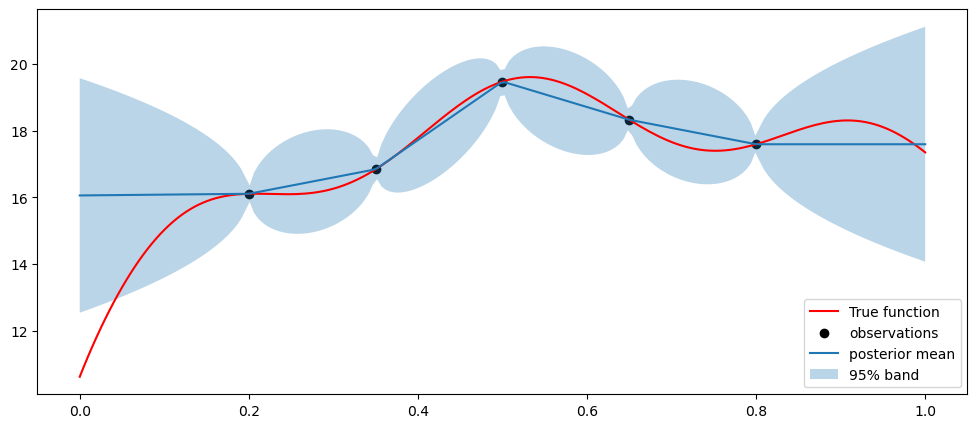

In [40]:
truth_grid = np.array([smoothfun(x) for x in grid])
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")

plt.plot(grid, post_mean_bm, label="posterior mean")

plt.fill_between(grid,
                 post_mean_bm-2*post_sd_bm,
                 post_mean_bm+2*post_sd_bm,
                 alpha=0.3,
                 label="95% band")

plt.legend()
plt.show()

Below we only plot the posterior mean. 

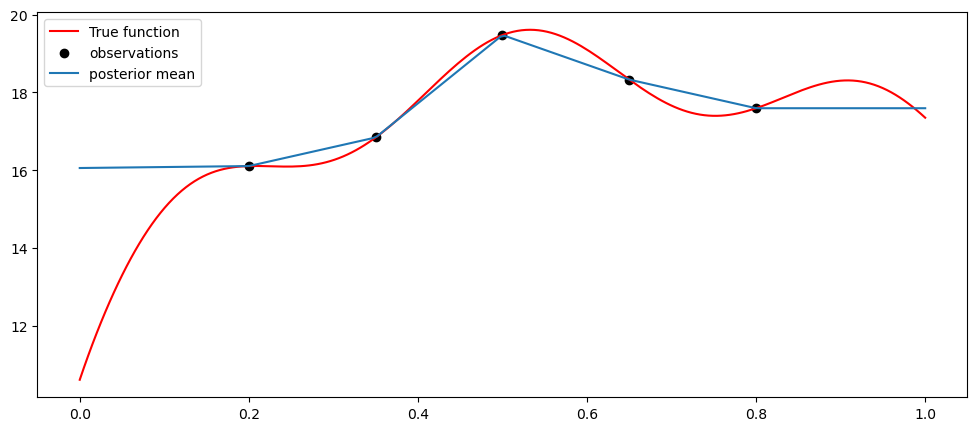

In [41]:
#Only plotting the posterior mean: 
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")
plt.plot(grid, post_mean_bm, label="posterior mean")
plt.legend()
plt.show()

Clearly the posterior mean linearly interpolates between the data. Go back and changes $x_1, \dots, x_n$ so they are random points in $[0, 1]$ which allows us to see that estimates beyond $[x_1, x_n]$ are constant. 

## Interpolation using Integrated Brownian Motion

Now we use the prior $f(x) = \beta_0 + \beta_1 x + \tau I(x)$ where $I(x)$ is integrated Brownian motion. The code for computing the posterior mean of $f(x)$ is same as below; the only change is in the formula for $K(u, v)$. 

In [42]:
# hyperparameters
tau = 100.0
C = 100000.0

# covariance of integrated Brownian motion
def kernel_IBM(s, t):
    m = min(s, t)
    M = max(s, t)
    return (m**2) * (3*M - m) / 6.0

# full kernel for f(x) = beta0 + beta1 x + tau I(x)
def kernel_f(s, t):
    return C + C*s*t + tau**2 * kernel_IBM(s, t)

# covariance matrix
K = np.array([[kernel_f(xi, xj) for xj in xx] for xi in xx])

# tiny jitter just for numerical stability
K = K + 1e-10 * np.eye(len(xx))

Kinv = np.linalg.inv(K)

# grid for prediction
grid = np.linspace(0, 1, 200)

post_mean_ibm = np.zeros(len(grid))
post_var_ibm = np.zeros(len(grid))

for i, x in enumerate(grid):
    kstar = np.array([kernel_f(x, xi) for xi in xx])
    kxx = kernel_f(x, x)

    post_mean_ibm[i] = kstar @ Kinv @ truth
    post_var_ibm[i] = kxx - kstar @ Kinv @ kstar

# guard against tiny negative values from floating point error
post_var_ibm = np.maximum(post_var_ibm, 0)
post_sd_ibm = np.sqrt(post_var_ibm)

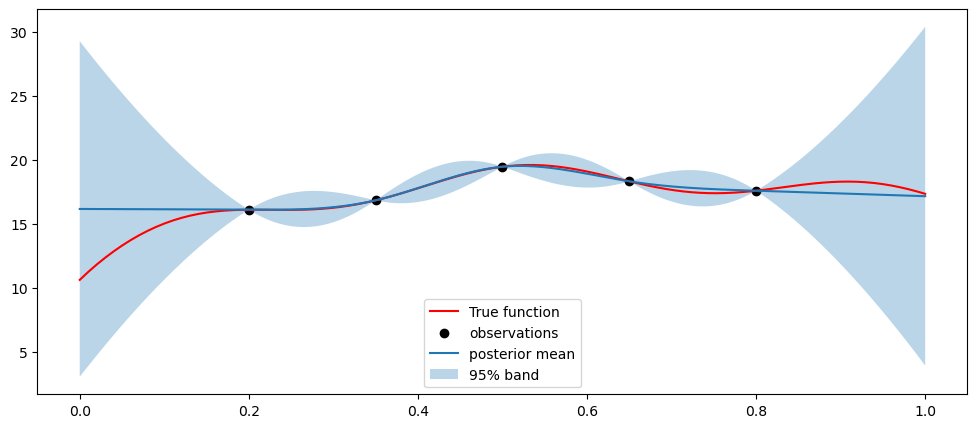

In [43]:
truth_grid = np.array([smoothfun(x) for x in grid])
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")

plt.plot(grid, post_mean_ibm, label="posterior mean")

plt.fill_between(grid,
                 post_mean_ibm-2*post_sd_ibm,
                 post_mean_ibm+2*post_sd_ibm,
                 alpha=0.3,
                 label="95% band")

plt.legend()
plt.show()

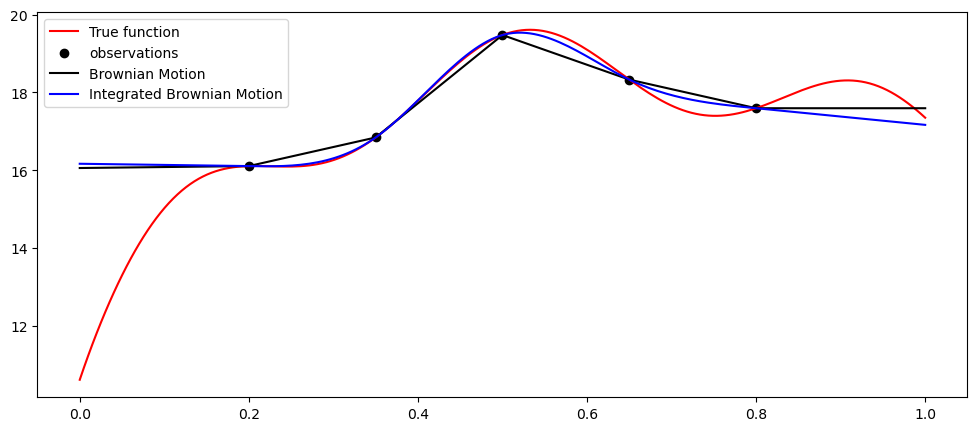

In [44]:
#Only plotting the posterior mean: 
plt.figure(figsize=(12,5))
plt.plot(grid, truth_grid, label="True function", color="red")
plt.scatter(xx,y,color="black",label="observations")
plt.plot(grid, post_mean_bm, label = 'Brownian Motion', color = 'black')
plt.plot(grid, post_mean_ibm, label = 'Integrated Brownian Motion', color = 'blue')
plt.legend()
plt.show()

The interpolant corresponding to this Integrated Brownian Motion prior is smooth (unlike the case of Brownian Motion) between the points. It, in fact, corresponds to a cubic spline interpolant. Beyond the observed data (i.e., before $x_1$ and after $x_n$), the interpolant turns out to be linear. 